# Defining Geometry Metadata in ESCDF

For a given test or analysis where responses are measured or computed, we will generally need to know the location at which the response was obtained, as well as the direction in which the response was obtained.  ESCDF uses the `geometry` data type to store this information.  This document will describe how ESCDF handles geometry definitions, as well as how they map to data that might also be stored in a given ESCDF file.

## Preliminary Setup
To start, we will perform preliminary operations needed by our respective programming languages. In Matlab, we clear and reset the workspace. In Python, we import our modules. In both cases, we need to ensure the respective libraries needed are on the Matlab or Python path.

In [1]:
# Geometry with ESCDF

# Import required packages
import sdynpy as sdpy  # SDynPy for it's exodus writers
import numpy as np  # NumPy for it's array capabilities
import matplotlib.pyplot as plt # Matplotlib to visualize geometry

# If ESCDF is not on your path, uncomment the following two lines and point the
# sys.path.append function to the ESCDF folder.

#import sys
#sys.path.append('/path/to/escdf')

import escdf  # escdf required to read and write ESCDF files

## Creation of the Source Geometry
A `geometry` object may come from many sources.  Geometry may come from the nodes of a finite element model; it may come from the measurement of sensor locations on a test; it may even come from a bespoke file type such as a Universal File, an STL file, or some other geometric representation.  Since this document cannot hope to cover all possible sources of geometry information, we will assume that we can extract whatever geometry information is needed from that source and package it into simple variables defining the positions of nodes in the geometry in ($x$, $y$, $z$) coordinates, as well as the unit vectors specifying the directions in which responses on that geometry might be obtained.

For this example, we will generate a conical geometry, and assume that measurements are made in local directions that are tangential and perpendicular to the cone's surface.  This first portion of the code will construct the geometry.  We will therefore generate positions corresponding to each node, as well as unit vectors for the local $x$, $y$, and $z$ coordinate system directions.

In [2]:
# Define the geometry of the cone
cone_angle = 10 # degrees
axial_stations = np.arange(0.1,2.5,0.3)
radial_stations = np.tan(cone_angle*np.pi/180)*axial_stations
circumferential_stations = np.arange(0,360,30)

# Go through and construct the array of node positions.
# We will construct it so the nodes are in a 2D array of
# axial stations and circumferential stations
node_positions = []
node_ids = []
node_x_directions = []
node_y_directions = []
node_z_directions = []
# Loop through axial and radial stations.  We will use enumerate
# to get the index as well as the values, and we will use zip
# to get one axial and one radial position with each loop.
for row_ind, (axial_position, radial_position) in enumerate(
    zip(axial_stations, radial_stations)):
    # Create an empty list to start the new row
    node_positions.append([])
    node_ids.append([])
    node_x_directions.append([])
    node_y_directions.append([])
    node_z_directions.append([])
    # Loop through circumferential stations, again using
    # enumerate to get the index as well as the value
    for col_ind, circumferential_position in enumerate(
        circumferential_stations):
        # Add an entry to the last row we constructed
        node_positions[-1].append([
            radial_position*np.cos(circumferential_position*np.pi/180),
            radial_position*np.sin(circumferential_position*np.pi/180),
            axial_position])
        # There are 12 circumferential stations, so we need to
        # start the axial identifiers in the 100's place of the
        # identification number.
        node_ids[-1].append(100*(row_ind+1) + col_ind+1) 
        # Create the rotation matrices for the coordinate system.
        # This will be a compound rotation, first about the Y-axis
        # we rotate the negative cone angle, then about the Z-axis
        # we rotate the negative circumferential station angle
        s = np.sin(-cone_angle*np.pi/180)
        c = np.cos(-cone_angle*np.pi/180)
        R_y = np.array([[c, 0, s],
                        [0, 1, 0],
                        [-s, 0, c]])
        s = np.sin(-circumferential_position*np.pi/180)
        c = np.cos(-circumferential_position*np.pi/180)
        R_z = np.array([[c, -s, 0],
                        [s, c, 0],
                        [0, 0, 1]])
        rot_mat =  R_y @ R_z
        # The unit vectors for each local direction are the rows
        # of the rotation matrix
        node_x_directions[-1].append(rot_mat[0,:])
        node_y_directions[-1].append(rot_mat[1,:])
        node_z_directions[-1].append(rot_mat[2,:])

# Transform into NumPy arrays
node_ids = np.array(node_ids).reshape(-1)
node_positions = np.array(node_positions).reshape(-1,3)
node_x_directions = np.array(node_x_directions).reshape(-1,3)
node_y_directions = np.array(node_y_directions).reshape(-1,3)
node_z_directions = np.array(node_z_directions).reshape(-1,3)

To visualize what the geometry looks like, we will plot the different local directions on the geometry on the $xz$ plane and $xy$ plane.

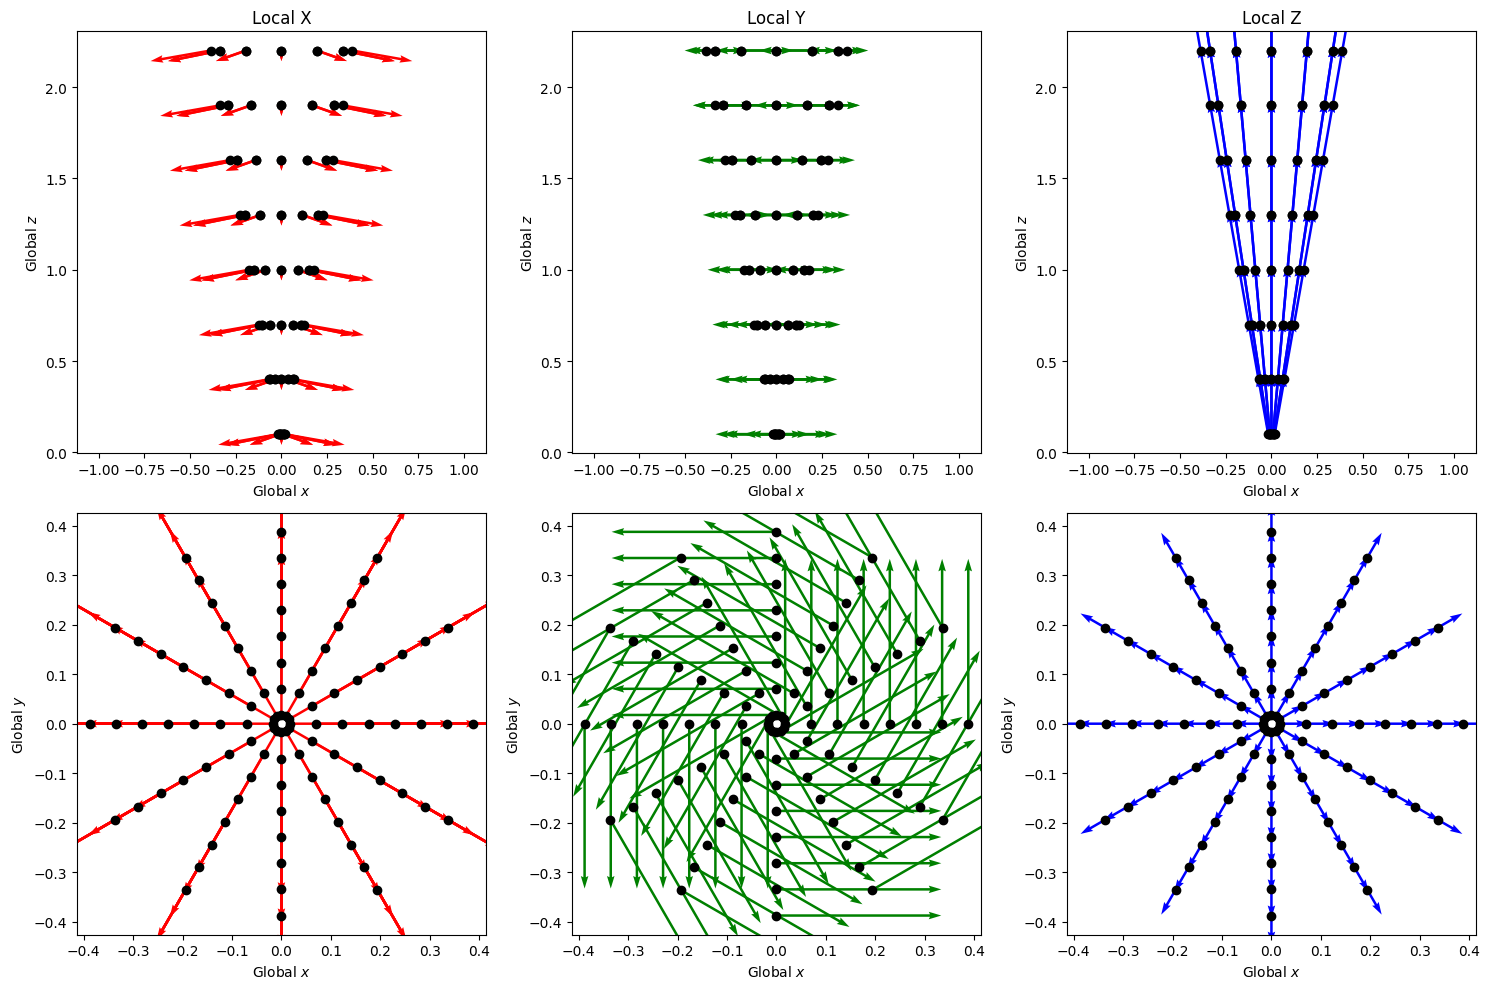

In [3]:
fig, axes = plt.subplots(2,3, figsize=(15,10))
for ax,direction,label,color in zip(
    axes.T,
    [node_x_directions, node_y_directions,node_z_directions],
    ['Local X','Local Y','Local Z'],
    ['r','g','b']):
    ax[0].axis('equal')
    x = node_positions[:,0]
    y = node_positions[:,2]
    ax[0].plot(x, y, 'ko')
    u = direction[:,0]
    v = direction[:,2]    
    ax[0].quiver(x,y,u,v,angles='xy',scale_units='xy',scale=3,color=color)
    ax[0].set_title(label)
    ax[0].set_ylabel('Global $z$')
    ax[0].set_xlabel('Global $x$')
    ax[1].axis('equal')
    x = node_positions[:,0]
    y = node_positions[:,1]
    ax[1].plot(x, y, 'ko')
    u = direction[:,0]
    v = direction[:,1]
    ax[1].quiver(x,y,u,v,angles='xy',scale_units='xy',scale=3,color=color)
    ax[1].set_ylabel('Global $y$')
    ax[1].set_xlabel('Global $x$')
fig.tight_layout()

We can see that the geometry is conical while also noting that the local $x$ directions all point perpendicular from the cone's surface, while the local $y$ directions point circumferentially and the $z$ directions point tangential to the cone's surface in the axial direction.

Note that many geometry sources may not include local coordinate system information.  For example, a finite element model typically assumes all data is in a global coordinate system.  If the case is such that all data is in the global coordinate system for a given activity, then the geometry should be defined such that all `node_x_direction` values are $(1, 0, 0)$, `node_y_direction` values are $(0, 1, 0)$, and `node_z_direction` values are $(0, 0, 1)$, which correspond to the global coordinate system directions.

## Creation of Data

For geometry to be meaningful, we might also wish to create a `data` object and a `mode` object, so we can investigate how we can use the geometry to better understand data and modal information using a geometry.  This data may come from a number of sources, such as a test or a simulation.  Therefore we will assume that the user can extract the data from whatever source the data originates from and can package it into standard arrays.  We will assume, as is typical, that data is measured and modes are fit in the local coordinate system directions.  If the users of the data wish to extract the data into a global coordinate system, they must leverage the geometry information along with the provided data or modal information to reconstruct these global motions.

To make data that is easy to visualize in this document, we will generate rigid motions.

In [4]:
# Create a translation motion
abscissa = np.linspace(0,10,201)
sine_signal = np.sin(2*np.pi*abscissa)
ordinates = []
data_channels = []
motion_direction = np.array([0.2,-0.5,0.3])

for node_index, node_number in enumerate(node_ids):
    for direction_index, (direction_label, direction_vector) in enumerate(zip(
        ['X-','Y-','Z+'],
        [node_x_directions,node_y_directions,node_z_directions])):
        data_channels.append(str(node_number)+direction_label)
        polarity = -1 if '-' in direction_label else 1
        coefficient = np.dot(direction_vector[node_index], motion_direction)*polarity
        ordinates.append(coefficient*sine_signal)

ordinates = np.array(ordinates)

We can visualize the different measurements we might have made for this response.

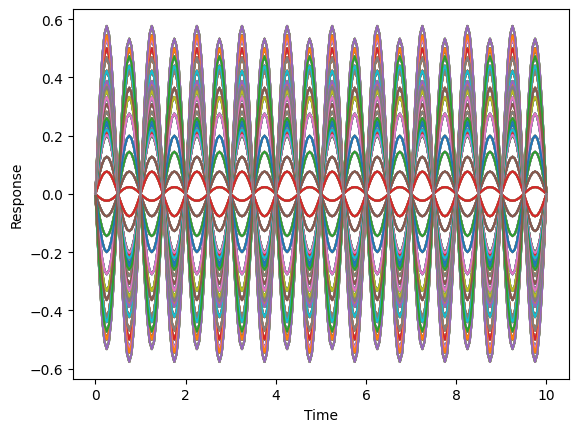

In [5]:
fig,ax = plt.subplots()
ax.plot(abscissa,ordinates.T)
ax.set_ylabel('Response')
ax.set_xlabel('Time');

Let's also generate some rigid body mode shapes.

In [6]:
shape_matrix = np.concatenate([-node_x_directions,-node_y_directions,node_z_directions])
shape_channels = [str(node_id)+direction_label for direction_label in ['X-','Y-','Z+'] for node_id in node_ids ]
frequencies = [0,0,0] # Rigid body shapes have 0 Hz frequencies
dampings = [0,0,0] # Rigid body shapes have undefined damping

## Creation of the ESCDF Geometry Object

We will create a dataset with the type `geometry`.  To see the various fields that must be specified, we can use Python's built-in `help` functionality or read the file in Matlab.

In [7]:
help(escdf.classes.geometry)

Help on class geometry in module escdf.escdf_class_factory:

class geometry(parameter_set)
 |  geometry(name, descriptive_name='', **kwargs)
 |
 |  This group defines a test or analysis geometry, which includes
 |  node positions and local directions associated with each node.
 |
 |  Properties
 |  ----------
 |
 |
 |      notes -- string -- (num_notes) -- This property is optional
 |
 |      attachments -- bytes -- (num_attachments) -- This property is optional
 |
 |      attachment_names -- string -- (num_attachments) -- This property is optional
 |
 |      node_id -- 64-bit unsigned integer -- (num_nodes)
 |
 |      node_position -- 64-bit floating-point number -- (num_nodes x 3)
 |
 |      node_x_direction -- 64-bit floating-point number -- (num_nodes x 3)
 |
 |      node_y_direction -- 64-bit floating-point number -- (num_nodes x 3)
 |
 |      node_z_direction -- 64-bit floating-point number -- (num_nodes x 3)
 |
 |      line_connection -- 64-bit unsigned integer -- (num_lines) --

We can then create the geometry dataset specifying `geometry` as the type and giving it a meaningful name and descriptive name.

In [8]:
es_geo = escdf.Dataset(
    'cone_geometry',
    'geometry',
    'A Geometric Representation of a Cone with Local Coordinate Systems')

We can interrogate this geometry object by typing the variable name `es_geo` into the console window to see the empty structure.

In [9]:
es_geo


  ESCDF Dataset: cone_geometry (geometry v0.1.0)

  Properties:

      attachment_names:
           attachments:
         element_color:
    element_connection:
          element_type:
            line_color:
       line_connection:
               node_id:
         node_position:
      node_x_direction:
      node_y_direction:
      node_z_direction:
                 notes:
        position_units:

Let's start populating the fields we have information for.  We know the node identification numbers, positions, and direction vectors, so we will start with those.

In [10]:
es_geo.node_id = node_ids
es_geo.node_position = node_positions
es_geo.node_x_direction = node_x_directions
es_geo.node_y_direction = node_y_directions
es_geo.node_z_direction = node_z_directions

We can use the `validate` method to identify if any required field is still missing.

In [11]:
es_geo.validate()

Required Property position_units is missing.


False

We can see that the `validate` method is telling us that the `property_units` are missing.  Basically, our geometry object needs to know if the `node_position` values are defined in meters, inches, or any other unit.  We will specify `'m'` here for units.

In [12]:
es_geo.position_units = 'm'
es_geo.validate()

True

Even though ESCDF may declare our geometry to be valid, there might be some additional content that we wish to add to the file.  For example, we could specify elements or tracelines on the geometry to improve visualizations; otherwise, the geometry is simply a point cloud that can be challenging to interpret.

To demonstrate different types of visualizations, we will use quadrilateral elements for the first few stations, then triangual elements for the next few, then tracelines for the last few stations.  Note that because the cone "wraps around" in the circumferential direction, we will append the starting circumferential station to the end of the array as well.

Because we made the node identification numbers follow a logical pattern, we could easily use them to, for example, create elements and lines on the geometry.  For each element, we need to specify a type and a connectivity array using the node identification numbers.  Each line needs only a connectivity.  We can also specify a color for each item.

In [13]:
quad_stations = [1,2,3]
tri_stations = [4,5,6]
line_stations = [7,8]
circumferential_nodes = [1,2,3,4,5,6,7,8,9,10,11,12,1] # Append 0 at the end

element_connectivity = []
element_types = []
element_colors = []
line_connectivity = []
line_colors = []

for axial_index in range(len(axial_stations)):
    axial_station = axial_index + 1
    for circumferential_index in range(len(circumferential_stations)):
        node_1 = 100*(axial_station) + circumferential_nodes[circumferential_index]
        node_2 = 100*(axial_station+1) + circumferential_nodes[circumferential_index]
        node_3 = 100*(axial_station+1) + circumferential_nodes[circumferential_index+1]
        node_4 = 100*(axial_station) + circumferential_nodes[circumferential_index+1]
        if axial_station < 3:
            # Quad element
            element_types.append('quad4')
            element_connectivity.append([node_1,node_2,node_3,node_4])
            element_colors.append([0,0,255]) # R G B
        elif axial_station < 6:
            # Tri Element
            element_types.append('tri3')
            element_connectivity.append([node_1,node_2,node_3])
            element_colors.append([255,0,0]) # R G B
            element_types.append('tri3')
            element_connectivity.append([node_1,node_3,node_4])
            element_colors.append([255,0,0]) # R G B
        # Otherwise it's tracelines which we will handle outside the circumferential loop.
    if axial_station >= 6:
        line_connectivity.append([100*(axial_station)+node for node in circumferential_nodes])
        line_colors.append([0,255,0]) # R G B

We can then apply these to our geometry dataset.

In [14]:
es_geo.element_connection = element_connectivity
es_geo.element_type = element_types
es_geo.element_color = element_colors
es_geo.line_connection = line_connectivity;
es_geo.line_color = line_colors

We now have our entire geometry completed.  We have defined the node positions, as well as the local orientations associated with measurements at each node.  We have defined the unit system that our geometry is defined in, and we have also added elements and tracelines to aid in visualization.

We will now proceed with constructing our data and shape objects and packaging it all together.

## Creating Data and Shape Objects

We will now create the data and shape objects that reference the geometries.  Again, we can see information about these types by using the Python `help` documentation or by reading the specification files in Matlab.

In [15]:
help(escdf.classes.mode)

Help on class mode in module escdf.escdf_class_factory:

class mode(activity_result)
 |  mode(name, descriptive_name='', **kwargs)
 |
 |  This defines a general format for storing modal data.
 |
 |  Properties
 |  ----------
 |
 |
 |      notes -- string -- (num_notes) -- This property is optional
 |
 |      attachments -- bytes -- (num_attachments) -- This property is optional
 |
 |      attachment_names -- string -- (num_attachments) -- This property is optional
 |
 |      frequency -- 64-bit floating-point number -- (num_modes)
 |
 |      damping_ratio -- 64-bit floating-point number -- (num_modes) -- This property is optional
 |
 |      modal_mass -- 64-bit floating-point number -- (num_modes) -- This property is optional
 |
 |      mode_type can be defined in multiple ways:
 |
 |          Case "real modes":
 |
 |              shape -- 64-bit floating-point number -- (num_dofs x num_modes)
 |
 |          Case "complex modes":
 |
 |              shape -- 128-bit complex floating-poi

In [16]:
help(escdf.classes.data)

Help on class data in module escdf.escdf_class_factory:

class data(activity_result)
 |  data(name, descriptive_name='', **kwargs)
 |
 |  This defines a general format for storing data.
 |  Specific types of data should inherit from this.
 |
 |  Properties
 |  ----------
 |
 |
 |      notes -- string -- (num_notes) -- This property is optional
 |
 |      attachments -- bytes -- (num_attachments) -- This property is optional
 |
 |      attachment_names -- string -- (num_attachments) -- This property is optional
 |
 |      data_type -- string -- (scalar) -- This property may only be assigned values defined in the enumeration data_types
 |
 |      channel -- string -- (num_data x num_channels) -- This property is specified by the regular expression ^\d+(R?[XYZ]{1,2}[+-])?$
 |
 |      channel_name -- string -- (num_data x num_channels) -- This property is optional
 |
 |      ordinate_unit can be defined in multiple ways:
 |
 |          Case "varying ordinate units":
 |
 |              ordi

We will now create the `mode` object, again giving a reasonable name and description.

In [17]:
es_mode = escdf.Dataset('rigid_modes','mode','Rigid shapes from a modal test.')

We can interrogate this object by typing the variable name `es_mode` in to the command window to identify what we need to define.

In [18]:
es_mode


  ESCDF Dataset: rigid_modes (mode v0.1.0)

  Properties:

    attachment_names:
         attachments:
       damping_ratio:
         description:
            dof_name:
           frequency:
          modal_mass:
               notes:
               shape:

We will then assign the variables we have already developed to this object.

In [19]:
es_mode.frequency = frequencies
es_mode.damping_ratio = dampings
es_mode.shape = shape_matrix
es_mode.dof_name = shape_channels

As always, we should validate to ensure that we have defined everything appropriately.

In [20]:
es_mode.validate()

True

We will do similarly with the data object.

In [21]:
es_data = escdf.Dataset('rigid_motion','data','Motions from a rigid body check')

Again we can interrogate this object:

In [22]:
es_data


  ESCDF Dataset: rigid_motion (data v0.1.0)

  Properties:

            abscissa:
      abscissa_start:
       abscissa_step:
       abscissa_unit:
    attachment_names:
         attachments:
             channel:
        channel_name:
           data_type:
               notes:
            ordinate:
       ordinate_unit:
           timestamp:

And then we can assign to it.

In [23]:
es_data.abscissa = abscissa
es_data.ordinate = ordinates
es_data.abscissa_unit = 's'
es_data.ordinate_unit = 'm/s^2'
# We need to make data_channels into an nx1 array
es_data.channel = np.array(data_channels)[:,np.newaxis]
es_data.data_type = 'time response'

And again `validate` for good measure:

In [24]:
es_data.validate()

True

## Packaging Objects into an ESCDF File
In order to save to disk, we need to store the data and metadata into an ESCDF File.  We will create the file, add an activity called `'modal_test'` and put the `data` and `mode` object into that activity.  We will then add the `geometry` metadata and link it to the activity.

In [25]:
import datetime
es_file = escdf.ESCDF()
es_file.add_activity(
    short_name = 'modal_test',
    descriptive_name = 'A modal test that acquired rigid body modes',
    activity_date = datetime.datetime.now())

Let's add the data to the activity.

In [26]:
es_file.add_data_to_activity(
    activity_name='modal_test',
    data = es_data)
es_file.add_data_to_activity(
    activity_name='modal_test',
    data = es_mode)

The geometry is not directly data generated by the activity; rather it is metadata that describes the data from the activity.  We will therefore add the geometry object as metadata to the file and link it to the activity.

In [27]:
es_file.add_metadata(es_geo, activity_to_link='modal_test')

We can then see the entire ESCDF file by typing `es_file` into the console window.

In [28]:
es_file


ESCDF
    Created by dprohe on 2026-05-13 11:26:21.935551

  Metadata:

    cone_geometry (geometry)

  Activities:

    modal_test:
      A modal test that acquired rigid body modes
      Date: 2026-05-13 11:26:21.935692
      Data: rigid_motion, rigid_modes
      Metadata: cone_geometry

Now we will write the entire file to disk so it can be shared with other stakeholders for this test.  We will specify the `clobber` argument to be `True` to ensure that any file on disk already is overwritten.

In [29]:
es_file.write_to_disk('modal_test.esf',clobber=True)

<HDF5 file "modal_test.esf" (mode r+)>

## Reading and using Geometry from an ESCDF File

After the file is shared, the users of the data may wish to extract the data and the geometry information.  This will be an exercise in bookkeeping.  Any data recieved in ESCDF format may be stored in local or global coordinate system.  **The user should never assume they know how the data is stored, but rather should always reference the linked geometry metadata to identify how the data is defined.**

We will load in the ESCDF file and begin to interrogate it, loading both data and shape results, and then referencing the geometry to transform the data to a global coordinate system for further analysis.

In [30]:
es_file = escdf.ESCDF.load('modal_test.esf')

We can interrogate the loaded file to see the various activity names and data objects.

In [31]:
es_file


ESCDF
    Created by dprohe on 2026-05-13 11:26:21.935551

  Metadata:

    cone_geometry (geometry)

  Activities:

    modal_test:
      A modal test that acquired rigid body modes
      Date: 2026-05-13 11:26:21.935692
      Data: rigid_modes, rigid_motion
      Metadata: cone_geometry

We can see there are two data objects in the `modal_test` activity: `rigid_modes` and `rigid_motion`.  We also see a linked metadata `cone_geometry` to this activity.

In the general case where there may be multiple activities and multiple geometries associated with those activities, we would like to specifically define the activity we would like to get data from, and use the metadata links to find the specific metadata associated with that activity.

In [32]:
# Extract the relevant activity
activity_name = 'modal_test'
activity = es_file.activities[activity_name]
activity_data = activity.data
# Pull out all metadata attached to the activity, and only keep geometry types.
activity_geometries = [metadata for metadata in es_file.get_activity_metadata(activity_name) if metadata.istype('geometry')]
# Check to make sure that we only got one geometry
if len(activity_geometries) == 0:
    raise ValueError('No Geometry Found!')
elif len(activity_geometries) > 1:
    raise ValueError('Multiple Geometries Found!')
else:
    activity_geometry = activity_geometries[0]

While this may be more code than simply writing `activity_geometry = es_file.metadata[0]` (Python) or `activity_geometry = es_file.metadata(1)` (Matlab), it is significantly more robust for general, reusable code.  We can verify that `activity_geometry` now points to our `cone_geometry` object.

In [33]:
activity_geometry


  ESCDF Dataset: cone_geometry (geometry v0.1.0)

  Properties:

      attachment_names:
           attachments:
         element_color: u8, (96, 3), on disk
    element_connection: u8, (96,), on disk
          element_type: str, (96,), on disk
            line_color: u8, (3, 3), on disk
       line_connection: u8, (3,), on disk
               node_id: u8, (96,), on disk
         node_position: f8, (96, 3), on disk
      node_x_direction: f8, (96, 3), on disk
      node_y_direction: f8, (96, 3), on disk
      node_z_direction: f8, (96, 3), on disk
                 notes:
        position_units: str, (), on disk

### Using Geometry to Interpret Mode Shapes

We'll start by investigating the modal data.  We can access this by indexing the `activity_data` with the dataset name in Python or calling the `get_data` method of the `activity` object in Matlab.

In [34]:
es_mode = activity_data['rigid_modes']

Depending on the information desired from the dataset, the actual analysis steps may be different.  For example, to determine if an accelerometer may have saturated during a test, one may be perfectly content to leave all data in its local coordinate system to perform the analysis.  However, other analyses, such as plotting a mode shape, may involve transforming to a global coordinate system for visualization.  We will assume that here.  We wish to construct a `node_displacements` vector that is the same size and ordering as `node_positions`, where each row corresponds to the $(x,y,z)$ displacement of that node.

For this effort, we will need to go through and multiply each shape coefficient by the corresponding unit vector, while also respecting polarity.  For example, the geometry's `node_x_direction` will specify the positive $x$ axis of the local coordinate system, so we will need to multiply that value by `-1` if we have measured, for example, $101X-$.

While there are perhaps more efficient ways to perform this analysis, recognizing, for example, that all of my local $x$-direction measurements are negative, this code will again present the most general, robust form of this analysis, so readers can use it to analyze arbitrary data.

We will start by extracting relevant geometry information and populating an empty array to store the node displacements.

In [35]:
# Extract relevant geometry information
node_ids = activity_geometry.node_id[...]
node_positions = activity_geometry.node_position[...]
node_x_directions = activity_geometry.node_x_direction[...]
node_y_directions = activity_geometry.node_y_direction[...]
node_z_directions = activity_geometry.node_z_direction[...]

# Create an empty array to populate with displacement data
node_displacements = np.zeros((node_ids.size, 3))

For documentation's sake, we will walk through the first item manually.  This will allow explanation of each step.  We will then combine this analysis into a `for` loop to automate the extraction of all data from the mode object.

We will start with the first index of the first shape in the shape matrix, and we will extract this shape coefficient from the shape matrix.

In [36]:
shape_index = 0
dof_index = 0
shape_coefficient = es_mode.shape[dof_index,shape_index]

Now we must figure out which degree of freedom this shape coefficient is associated with and how that maps to our `node_displacements` array.  We will interrogate the `dof_name` property to find the channel names.

In [37]:
dof_name = es_mode.dof_name[dof_index]
dof_name

'101X-'

We see that the coefficient corresponds to node 101, and this shape is in the negative $x$ direction.  We therefore need to find the `node_x_direction` associated with node 101, as well as the row into the `node_displacements` array.  We should do this in an automated way so we can execute these operations within a future `for` loop.  Though our current measurements do not contain rotations, general measurements might, so we will also put some error checking into our code to tell users that our code won't work with rotations.

In [38]:
if 'R' in dof_name:
    raise ValueError("We can't handle Rotations yet!")
# The node number is up to the 2nd to last item in the name
node_id = int(dof_name[:-2])
# The second to last item in the array is the direction
direction_name = dof_name[-2]
# The last item in the array is the polarity
polarity = -1 if dof_name[-1]=='-' else 1
print(f'Analyzing node {node_id} in direction {direction_name} with polarity {polarity}')

Analyzing node 101 in direction X with polarity -1


We should then find the correct index into the node array corresponding to this node number.

In [39]:
node_index = np.where(node_id == node_ids)
print(f'Node number {node_id} is at index {node_index[0][0]}.')

Node number 101 is at index 0.


Now we can extract the correct local direction for that degree of freedom, which when multiplied by the shape coefficient and polarity will give the correct displacement for that component.

In [40]:
if direction_name.lower() == 'x':
    direction = node_x_directions[node_index]
elif direction_name.lower() == 'y':
    direction = node_y_directions[node_index]
elif direction_name.lower() == 'z':
    direction = node_z_directions[node_index]
else:
    raise ValueError(f'Invalid Direction Name {direction_name}')

displacement = polarity*shape_coefficient*direction
print(f'Degree of Freedom {dof_name} is moving {displacement}')

Degree of Freedom 101X- is moving [[ 0.96984631  0.         -0.17101007]]


We can then add this to our `node_displacements` array at the corresponding node index.  Note that we don't simply assign this value to the `node_displacements` variable at the relevant index.  Each local direction will contribute to the global displacement, so we need to add these contributions together rather than overwrite the contributions.

In [41]:
node_displacements[node_index] = node_displacements[node_index] + displacement

We can easily package this into a `for` loop that will read all degrees of freedom and shape coefficients.

In [42]:
# Create an empty array to populate with displacement data
node_displacements = np.zeros((node_ids.size, 3))

for dof_name, shape_coefficient in zip(es_mode.dof_name, es_mode.shape[:,shape_index]):
    if 'R' in dof_name:
        raise ValueError("We can't handle Rotations yet!")
    # The node number is up to the 2nd to last item in the name
    node_id = int(dof_name[:-2])
    # The second to last item in the array is the direction
    direction_name = dof_name[-2]
    # The last item in the array is the polarity
    polarity = -1 if dof_name[-1]=='-' else 1
    print(f'Analyzing node {node_id} in direction {direction_name} with polarity {polarity}')
    node_index = np.where(node_id == node_ids)
    print(f'  Node number {node_id} is at index {node_index[0][0]}.')
    if direction_name.lower() == 'x':
        direction = node_x_directions[node_index]
    elif direction_name.lower() == 'y':
        direction = node_y_directions[node_index]
    elif direction_name.lower() == 'z':
        direction = node_z_directions[node_index]
    else:
        raise ValueError(f'  Invalid Direction Name {direction_name}')
    
    displacement = polarity*shape_coefficient*direction
    print(f'  Degree of Freedom {dof_name} is moving {displacement}')

    node_displacements[node_index] = node_displacements[node_index] + displacement

Analyzing node 101 in direction X with polarity -1
  Node number 101 is at index 0.
  Degree of Freedom 101X- is moving [[ 0.96984631  0.         -0.17101007]]
Analyzing node 102 in direction X with polarity -1
  Node number 102 is at index 1.
  Degree of Freedom 102X- is moving [[ 0.72738473  0.41995577 -0.14809907]]
Analyzing node 103 in direction X with polarity -1
  Node number 103 is at index 2.
  Degree of Freedom 103X- is moving [[ 0.24246158  0.41995577 -0.08550504]]
Analyzing node 104 in direction X with polarity -1
  Node number 104 is at index 3.
  Degree of Freedom 104X- is moving [[ 3.63634123e-33  5.93859590e-17 -1.04713468e-17]]
Analyzing node 105 in direction X with polarity -1
  Node number 105 is at index 4.
  Degree of Freedom 105X- is moving [[ 0.24246158 -0.41995577  0.08550504]]
Analyzing node 106 in direction X with polarity -1
  Node number 106 is at index 5.
  Degree of Freedom 106X- is moving [[ 0.72738473 -0.41995577  0.14809907]]
Analyzing node 107 in direct

Because we constructed the rigid shapes for this example as the displacements in the global $x$, $y$, and $z$ directions, we see that when we reconstruct the global displacements we indeed end up with the vector `[1, 0, 0]` for each node in the model in the first mode shape.

In [43]:
node_displacements

array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.00000000e+00,  8.67361738e-18,  0.00000000e+00],
       [ 1.00000000e+00, -4.51028104e-17, -1.38777878e-17],
       [ 1.00000000e+00, -6.93334780e-33,  0.00000000e+00],
       [ 1.00000000e+00,  5.03069808e-17,  0.00000000e+00],
       [ 1.00000000e+00, -8.67361738e-18,  0.00000000e+00],
       [ 1.00000000e+00,  1.38666956e-32,  0.00000000e+00],
       [ 1.00000000e+00, -4.51028104e-17,  0.00000000e+00],
       [ 1.00000000e+00, -3.64291930e-17,  0.00000000e+00],
       [ 1.00000000e+00,  3.08148791e-33,  0.00000000e+00],
       [ 1.00000000e+00,  4.51028104e-17, -1.38777878e-17],
       [ 1.00000000e+00,  3.64291930e-17,  0.00000000e+00],
       [ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.00000000e+00,  8.67361738e-18,  0.00000000e+00],
       [ 1.00000000e+00, -4.51028104e-17, -1.38777878e-17],
       [ 1.00000000e+00, -6.93334780e-33,  0.00000000e+00],
       [ 1.00000000e+00,  5.03069808e-17

Note, however, that this has only performed the transformation operation for the first mode in the mode shape matrix.  We may wish to repeat this operation for each mode and construct a complete "global mode shape matrix" that is `num_dofs` $\times$ `num_modes`.  We would then flatten this array and perform the same operation for each mode.  It would generally be useful to package a tool like this into a generic function that can be pointed at any dataset.  In this case we will handle the rotations as well, creating a second shape matrix for rotations if requested.

In [44]:
import re
def transform_shapes_to_global(es_mode : escdf.Dataset, es_geo : escdf.Dataset,
                               return_rotations : bool = False,
                               verbose : bool = False):
    """Accepts a "mode" dataset and converts the shapes to global.

    Parameters
    ----------
    es_mode : escdf.Dataset
        An ESCDF dataset with type "mode" containing the mode shape information.
    es_geo : escdf.Dataset
        An ESCDF dataset with type "geometry" containing the local displacement
        directions.
    return_rotations : bool
        If True, will return a second shape coefficient matrix containing the 
        rotational degrees of freedom.
    verbose : bool
        If True, will print debugging and status statements throughout execution.

    Returns
    -------
    global_dof_names : np.ndarray
        An array of degree of freedom names specifying node and global displacement
        direction.
    global_shape_displacement_matrix : np.ndarray
        A (num_channels x num_modes) array consisting of shape coefficients
        for displacements converted to the global coordinate system.
    global_shape_rotation_matrix : np.ndarray
        A (num_channels x num_modes) array consisting of shape coefficients
        for rotations converted to the global coordinate system.  Only returned
        if `return_rotations` is `True`.
    """
    # Set up initial sizes of output arrays
    num_modes = es_mode.shape.shape[-1]
    num_nodes = es_geo.node_id.shape[0]
    # Extract node numbers from the geometry
    node_ids = es_geo.node_id[...]
    # Create a mapping between ID number and index
    node_index_mapping = {id:index for index,id in enumerate(node_ids)}
    # Create empty output arrays
    global_shape_displacement_matrix = np.zeros((num_nodes,3,num_modes),dtype=es_mode.shape.datatype)
    if verbose:
        print(f'Created {global_shape_displacement_matrix.shape} output array for displacements')
    if return_rotations:
        global_shape_rotation_matrix = np.zeros((num_nodes,3,num_modes),dtype=es_mode.shape.datatype)
        if verbose:
            print(f'Created {global_shape_rotation_matrix.shape} output array for rotations')
    # Create output degree of freedom list
    global_dof_names = [str(id) + direction for id in node_ids for direction in ['X+','Y+','Z+']]
    if verbose:
        print(f'Created output degree of freedom names:\n{global_dof_names}')
    # Set up a name pattern for regular expressions
    name_pattern = '(\d+)([a-zA-Z]+)([+-])';
    # Loop through each degree of freedom and shape row
    for dof_name,shape_row in zip(es_mode.dof_name, es_mode.shape):
        # Match the name using regular expressions
        name_match = re.match(name_pattern,dof_name)
        node_id = int(name_match.group(1))
        direction_str = name_match.group(2)
        polarity = int(name_match.group(3)+'1')
        if 'R' in direction_str and not return_rotations:
            if verbose:
                print(f'Skipping DoF {dof_name} because rotations not requested.')
            continue
        if verbose:
            print(f'Analyzing DoF {dof_name} with node number {node_id}, '
                  f'direction {direction_str}, and polarity {polarity}')
        # Get the node index for this node numbers
        node_index = node_index_mapping[node_id]
        if verbose:
            print(f'  Node {node_id} is at index {node_index}')
        # Use the direction string to select the correct direction vector
        if 'X' in direction_str:
            direction = polarity*es_geo.node_x_direction[node_index,:]
        elif 'Y' in direction_str:
            direction = polarity*es_geo.node_y_direction[node_index,:]
        elif 'Z' in direction_str:
            direction = polarity*es_geo.node_z_direction[node_index,:]
        else:
            raise ValueError('Unknown Direction')
        if verbose:
            print(f'  DoF {dof_name} is pointing {direction}')
        # Multiply the shape coefficients by the direction vector using
        # broadcasting to get a 3 x num_modes array of contributions
        dof_contributions = (direction[:,np.newaxis] # 3 x 1 because of newaxis
                            * shape_row) # (1 x) num_modes
        if verbose:
            print(f'  DoF {dof_name} contributions:\n{dof_contributions}')
        # We will then add this 3 x num_modes contribution into the
        # correct output matrix (rotation vs displacement) at the correct
        # node index.
        if 'R' in direction_str:
            global_shape_rotation_matrix[node_index] += dof_contributions
        else:
            global_shape_displacement_matrix[node_index] += dof_contributions
    # At the end, we should flatten these matrices so they are num_dof x num_mode
    # instead of num_node x 3 x num_mode.
    if return_rotations:
        return (
            global_dof_names,
            global_shape_displacement_matrix.reshape(-1,num_modes),
            global_shape_rotation_matrix.reshape(-1,num_modes)
        )
    else:
        return (
            global_dof_names,
            global_shape_displacement_matrix.reshape(-1,num_modes)
        )
    

Let's call this function on our data to verify that it works correctly.

In [45]:
dof_names, global_displacements, global_rotations = transform_shapes_to_global(es_mode, es_geo, return_rotations=True)

We can set up a `DataFrame` to present this data in a nice way.

In [46]:
# Import Pandas to generate a data frame
import pandas as pd

df_disp = pd.DataFrame(
    global_displacements,
    index = dof_names,
    columns = [f'Mode {i+1}' for i in range(global_displacements.shape[-1])])
df_rot = pd.DataFrame(
    global_rotations,
    index = dof_names,
    columns = [f'Mode {i+1}' for i in range(global_rotations.shape[-1])])

We can verify that for the global $x$-direction mode, all global $x$ degrees of freedom have a shape coefficient of 1, and likewise for $y$ and $z$.

In [47]:
df_disp

,Mode 1,Mode 2,Mode 3
101X+,1.000000e+00,0.000000e+00,0.0
101Y+,0.000000e+00,1.000000e+00,0.0
101Z+,0.000000e+00,0.000000e+00,1.0
102X+,1.000000e+00,8.673617e-18,0.0
102Y+,8.673617e-18,1.000000e+00,0.0
...,...,...,...
811Y+,4.510281e-17,1.000000e+00,0.0
811Z+,-1.387779e-17,0.000000e+00,1.0
812X+,1.000000e+00,3.642919e-17,0.0
812Y+,3.642919e-17,1.000000e+00,0.0


Similarly, we can verify that there were no rotations in the model, so the rotation matrix is zeros.

In [48]:
df_rot

,Mode 1,Mode 2,Mode 3
101X+,0.0,0.0,0.0
101Y+,0.0,0.0,0.0
101Z+,0.0,0.0,0.0
102X+,0.0,0.0,0.0
102Y+,0.0,0.0,0.0
...,...,...,...
811Y+,0.0,0.0,0.0
811Z+,0.0,0.0,0.0
812X+,0.0,0.0,0.0
812Y+,0.0,0.0,0.0


### Using Geometry to Interpret Data

Now we will interpret the time data, utilizing the geometry to aid in transforming the data to a global coordinate system for visualization.

In [49]:
es_data = activity_data['rigid_motion']

Depending on the information desired and the type of data, the actual analysis steps may be different.  For example, to determine if an accelerometer may have saturated during a test, one may be perfectly content to leave all data in its local coordinate system to perform the analysis.  However, other analyses, such as plotting deflections over time, may involve transforming to a global coordinate system for visualization.  We will assume that here.  Additionally, if other types of data were provided instead of a time history, such as a power spectral density or frequency response function, then the steps to transform the coordinate systems of those data may involve multiple transformation steps for the "row" and "column degrees of freedom.

In this case, we wish to construct a `node_displacements` array that is the same size and ordering as `node_positions`, where each row corresponds to the $(x, y, z)$ displacement of that node.

For this effort, we will need to go through and multiply each local displacement by the corresponding unit vector of that degree of freedom, while also respecting polarity.  For example, the geometry’s `node_x_direction` will specify the positive $x$ axis of the local coordinate system, so we will need to multiply that value by -1 if we have measured, for example, $101X−$.

While there are perhaps more efficient ways to perform this analysis, recognizing, for example, that all of the local $x$-direction measurements are negative, this code will again present the most general, robust form of this analysis so readers can use it to analyze arbitrary data.

We will start by extracting relevant geometry information and populating an empty array to store the node displacements.

In [50]:
# Extract relevant geometry information
node_ids = activity_geometry.node_id[...]
node_positions = activity_geometry.node_position[...]
node_x_directions = activity_geometry.node_x_direction[...]
node_y_directions = activity_geometry.node_y_direction[...]
node_z_directions = activity_geometry.node_z_direction[...]

# Create an empty array to populate with displacement data
node_displacements = np.zeros((node_ids.size, 3))

For documentation's sake, we will walk through the first item manually.  This will allow for explaination of each step.  We will then combine this analysis into a `for` loop to automate extraction of all data from the `data` object.

Since our time response starts at 0 displacement, we will skip the first time step and start looking at the second time step to demonstrate the process (otherwise we will simply recover an array of zeros, which will not give us the intuition that we have set up the analysis correctly).  We will start with the index of the second time step in the data, and we will extract the displacement value from the ordinate.

In [51]:
timestep_index = 1
dof_index = 0
local_disp = es_data.ordinate[dof_index, timestep_index]

Now we must figure out which degree of freedom this shape coefficient is associated with and how that maps to our `node_displacements` array.  We will interrogate the `channel` property to find the channel names.

Recall that the `channel` shape is actually `num_data` $\times$ `num_channels`, because it can store higher dimensional datasets like frequency response functions or cross-power spectral density functions, which may contain more than one degree of freedom per function; for example each frequency response function has both a response degree of freedom and a reference degree of freedom.  For a time history, there is only one channel associated with each signal, so the `channel` property has a shape of `num_data` $\times$ `1`, but it is still two dimensional and needs two indices.

In [52]:
dof_name = es_data.channel[dof_index,0] # Index of 0 grabs the only column in the second dimension.
dof_name

'101X-'

We see that the coefficient corresponds to node 101, and this shape is in the negative $x$ direction. We therefore need to find the `node_x_direction` associated with node 101, as well as the row index into the `node_displacements` array. We should do this in an automated way so we can execute these operations within a future for loop. Though our current measurements do not contain rotations, general measurements might, so we will also put some error checking into our code to tell users that our code won’t work with rotations.

In [53]:
if 'R' in dof_name:
    raise ValueError("We can't handle Rotations yet!")
# The node number is up to the 2nd to last item in the name
node_id = int(dof_name[:-2])
# The second to last item in the array is the direction
direction_name = dof_name[-2]
# The last item in the array is the polarity
polarity = -1 if dof_name[-1]=='-' else 1
print(f'Analyzing node {node_id} in direction {direction_name} with polarity {polarity}')

Analyzing node 101 in direction X with polarity -1


We should then find the correct index into the node array corresponding to this node number.

In [54]:
node_index = np.where(node_id == node_ids)
print(f'Node number {node_id} is at index {node_index[0][0]}.')

Node number 101 is at index 0.


Now we can extract the correct local direction for that degree of freedom, which when multiplied by the local displacement and polarity will give the correct displacement for that component.

In [55]:
if direction_name.lower() == 'x':
    direction = node_x_directions[node_index]
elif direction_name.lower() == 'y':
    direction = node_y_directions[node_index]
elif direction_name.lower() == 'z':
    direction = node_z_directions[node_index]
else:
    raise ValueError(f'Invalid Direction Name {direction_name}')

displacement = polarity*local_disp*direction
print(f'Degree of Freedom {dof_name} is moving {displacement}')

Degree of Freedom 101X- is moving [[ 0.04408629  0.         -0.0077736 ]]


We can then add this to our `node_displacements` array at the corresponding node index. Note that we don’t simply assign this value to the `node_displacements` variable at the relevant index. Each local direction will contribute to the global displacement, so we need to add these contributions together rather than overwrite the contributions.

In [56]:
node_displacements[node_index] = node_displacements[node_index] + displacement

We can easily package this into a `for` loop that will read all degrees of freedom and local displacement values.

In [57]:
# Create an empty array to populate with displacement data
node_displacements = np.zeros((node_ids.size, 3))

for dof_name, local_disp in zip(es_data.channel[:,0], es_data.ordinate[:,timestep_index]):
    if 'R' in dof_name:
        raise ValueError("We can't handle Rotations yet!")
    # The node number is up to the 2nd to last item in the name
    node_id = int(dof_name[:-2])
    # The second to last item in the array is the direction
    direction_name = dof_name[-2]
    # The last item in the array is the polarity
    polarity = -1 if dof_name[-1]=='-' else 1
    print(f'Analyzing node {node_id} in direction {direction_name} with polarity {polarity}')
    node_index = np.where(node_id == node_ids)
    print(f'  Node number {node_id} is at index {node_index[0][0]}.')
    if direction_name.lower() == 'x':
        direction = node_x_directions[node_index]
    elif direction_name.lower() == 'y':
        direction = node_y_directions[node_index]
    elif direction_name.lower() == 'z':
        direction = node_z_directions[node_index]
    else:
        raise ValueError(f'  Invalid Direction Name {direction_name}')
    
    displacement = polarity*local_disp*direction
    print(f'  Degree of Freedom {dof_name} is moving {displacement}')

    node_displacements[node_index] = node_displacements[node_index] + displacement

Analyzing node 101 in direction X with polarity -1
  Node number 101 is at index 0.
  Degree of Freedom 101X- is moving [[ 0.04408629  0.         -0.0077736 ]]
Analyzing node 101 in direction Y with polarity -1
  Node number 101 is at index 0.
  Degree of Freedom 101Y- is moving [[-0.        -0.1545085 -0.       ]]
Analyzing node 101 in direction Z with polarity 1
  Node number 101 is at index 0.
  Degree of Freedom 101Z+ is moving [[0.01771711 0.         0.1004787 ]]
Analyzing node 102 in direction X with polarity -1
  Node number 102 is at index 1.
  Degree of Freedom 102X- is moving [[-0.03366142 -0.01943443  0.00685363]]
Analyzing node 102 in direction Y with polarity -1
  Node number 102 is at index 1.
  Degree of Freedom 102Y- is moving [[ 0.08235499 -0.14264303 -0.        ]]
Analyzing node 102 in direction Z with polarity 1
  Node number 102 is at index 1.
  Degree of Freedom 102Z+ is moving [[0.01310983 0.00756897 0.08585147]]
Analyzing node 103 in direction X with polarity -1


We constructed the global response with sinusoidal motion in the direction

In [58]:
motion_direction

array([ 0.2, -0.5,  0.3])

We can therefore see that the displacements we have recovered are some fraction of this value; all displacements are equal to `0.30901699` times the motion direction.

In [59]:
node_displacements/motion_direction

array([[0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.30901699, 0.30901699, 0.30901699],
       [0.

Note, however, that this has only performed the transformation operation on the second time step of the response.  We would generally wish to repeat this operation for each time step and contruct a complete "global time response" array that is `num_dofs` $\times$ `num_timesteps`.  We would then flatten this array and perform the same operation for each time step.  It would generally be useful to package a tool like this into a generic function that can be pointed at any dataset.  In this case, we will handle the rotations as well, creating a second time history array for rotations if requested.

In [60]:
import re
def transform_time_data_to_global(es_data : escdf.Dataset, es_geo : escdf.Dataset,
                                  return_rotations : bool = False,
                                  verbose : bool = False):
    """Accepts a "data" dataset and converts the ordinate to global.

    Parameters
    ----------
    es_data : escdf.Dataset
        An ESCDF dataset with type "data" containing the time response information.
    es_geo : escdf.Dataset
        An ESCDF dataset with type "geometry" containing the local displacement
        directions.
    return_rotations : bool
        If True, will return a second displacement matrix containing the 
        rotational degrees of freedom.
    verbose : bool
        If True, will print debugging and status statements throughout execution.

    Returns
    -------
    global_dof_names : np.ndarray
        An array of degree of freedom names specifying node and global displacement
        direction.
    global_displacement_matrix : np.ndarray
        A (num_channels x num_timesteps) array consisting of shape coefficients
        for displacements converted to the global coordinate system.
    global_rotation_matrix : np.ndarray
        A (num_channels x num_timesteps) array consisting of shape coefficients
        for rotations converted to the global coordinate system.  Only returned
        if `return_rotations` is `True`.
    """
    if es_data.data_type[...] != 'time response':
        raise ValueError('`transform_time_data_to_global` only works on `"time response"` data.')
    # Set up initial sizes of output arrays
    num_timesteps = es_data.ordinate.shape[-1]
    num_nodes = es_geo.node_id.shape[0]
    # Extract node numbers from the geometry
    node_ids = es_geo.node_id[...]
    # Create a mapping between ID number and index
    node_index_mapping = {id:index for index,id in enumerate(node_ids)}
    # Create empty output arrays
    global_displacement_matrix = np.zeros((num_nodes,3,num_timesteps))
    if verbose:
        print(f'Created {global_displacement_matrix.shape} output array for displacements')
    if return_rotations:
        global_rotation_matrix = np.zeros((num_nodes,3,num_timesteps))
        if verbose:
            print(f'Created {global_rotation_matrix.shape} output array for rotations')
    # Create output degree of freedom list
    global_dof_names = [str(id) + direction for id in node_ids for direction in ['X+','Y+','Z+']]
    if verbose:
        print(f'Created output degree of freedom names:\n{global_dof_names}')
    # Set up a name pattern for regular expressions
    name_pattern = '(\d+)([a-zA-Z]+)([+-])';
    # Loop through each degree of freedom and shape row
    for dof_name,ordinate_row in zip(es_data.channel[:,0], es_data.ordinate):
        # Match the name using regular expressions
        name_match = re.match(name_pattern,dof_name)
        node_id = int(name_match.group(1))
        direction_str = name_match.group(2)
        polarity = int(name_match.group(3)+'1')
        if 'R' in direction_str and not return_rotations:
            if verbose:
                print(f'Skipping DoF {dof_name} because rotations not requested.')
            continue
        if verbose:
            print(f'Analyzing DoF {dof_name} with node number {node_id}, '
                  f'direction {direction_str}, and polarity {polarity}')
        # Get the node index for this node numbers
        node_index = node_index_mapping[node_id]
        if verbose:
            print(f'  Node {node_id} is at index {node_index}')
        # Use the direction string to select the correct direction vector
        if 'X' in direction_str:
            direction = polarity*es_geo.node_x_direction[node_index,:]
        elif 'Y' in direction_str:
            direction = polarity*es_geo.node_y_direction[node_index,:]
        elif 'Z' in direction_str:
            direction = polarity*es_geo.node_z_direction[node_index,:]
        else:
            raise ValueError('Unknown Direction')
        if verbose:
            print(f'  DoF {dof_name} is pointing {direction}')
        # Multiply the shape coefficients by the direction vector using
        # broadcasting to get a 3 x num_timesteps array of contributions
        dof_contributions = (direction[:,np.newaxis] # 3 x 1 because of newaxis
                            * ordinate_row) # (1 x) num_timesteps
        if verbose:
            print(f'  DoF {dof_name} contributions:\n{dof_contributions}')
        # We will then add this 3 x num_modes contribution into the
        # correct output matrix (rotation vs displacement) at the correct
        # node index.
        if 'R' in direction_str:
            global_rotation_matrix[node_index] += dof_contributions
        else:
            global_displacement_matrix[node_index] += dof_contributions
    # At the end, we should flatten these matrices so they are num_dof x num_mode
    # instead of num_node x 3 x num_mode.
    if return_rotations:
        return (
            global_dof_names,
            global_displacement_matrix.reshape(-1,num_timesteps),
            global_rotation_matrix.reshape(-1,num_timesteps)
        )
    else:
        return (
            global_dof_names,
            global_displacement_matrix.reshape(-1,num_timesteps)
        )

Let's call this function on our data to verify that it works correctly.

In [61]:
dof_names, global_displacements, global_rotations = transform_time_data_to_global(es_data, es_geo, return_rotations=True)

We can set up a `DataFrame` to present this data in a nice way.

In [62]:
# Import Pandas to display a dataframe
import pandas as pd

df_disp = pd.DataFrame(
    global_displacements,
    index = dof_names,
    columns = [f'{t=:0.2f}s' for t in es_data.abscissa])
df_rot = pd.DataFrame(
    global_rotations,
    index = dof_names,
    columns = [f'{t=:0.2f}s' for t in es_data.abscissa])

We can verify that the translation looks rigid.  All $x$-values are identical at each time step, likewise for $y$ and $z$.

In [63]:
df_disp

,t=0.00s,t=0.05s,t=0.10s,t=0.15s,t=0.20s,t=0.25s,t=0.30s,t=0.35s,t=0.40s,t=0.45s,...,t=9.55s,t=9.60s,t=9.65s,t=9.70s,t=9.75s,t=9.80s,t=9.85s,t=9.90s,t=9.95s,t=10.00s
101X+,0.0,0.061803,0.117557,0.161803,0.190211,0.2,0.190211,0.161803,0.117557,0.061803,...,-0.061803,-0.117557,-0.161803,-0.190211,-0.2,-0.190211,-0.161803,-0.117557,-0.061803,-4.898587e-16
101Y+,0.0,-0.154508,-0.293893,-0.404508,-0.475528,-0.5,-0.475528,-0.404508,-0.293893,-0.154508,...,0.154508,0.293893,0.404508,0.475528,0.5,0.475528,0.404508,0.293893,0.154508,1.224647e-15
101Z+,0.0,0.092705,0.176336,0.242705,0.285317,0.3,0.285317,0.242705,0.176336,0.092705,...,-0.092705,-0.176336,-0.242705,-0.285317,-0.3,-0.285317,-0.242705,-0.176336,-0.092705,-7.347881e-16
102X+,0.0,0.061803,0.117557,0.161803,0.190211,0.2,0.190211,0.161803,0.117557,0.061803,...,-0.061803,-0.117557,-0.161803,-0.190211,-0.2,-0.190211,-0.161803,-0.117557,-0.061803,-4.898587e-16
102Y+,0.0,-0.154508,-0.293893,-0.404508,-0.475528,-0.5,-0.475528,-0.404508,-0.293893,-0.154508,...,0.154508,0.293893,0.404508,0.475528,0.5,0.475528,0.404508,0.293893,0.154508,1.224647e-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811Y+,0.0,-0.154508,-0.293893,-0.404508,-0.475528,-0.5,-0.475528,-0.404508,-0.293893,-0.154508,...,0.154508,0.293893,0.404508,0.475528,0.5,0.475528,0.404508,0.293893,0.154508,1.224647e-15
811Z+,0.0,0.092705,0.176336,0.242705,0.285317,0.3,0.285317,0.242705,0.176336,0.092705,...,-0.092705,-0.176336,-0.242705,-0.285317,-0.3,-0.285317,-0.242705,-0.176336,-0.092705,-7.347881e-16
812X+,0.0,0.061803,0.117557,0.161803,0.190211,0.2,0.190211,0.161803,0.117557,0.061803,...,-0.061803,-0.117557,-0.161803,-0.190211,-0.2,-0.190211,-0.161803,-0.117557,-0.061803,-4.898587e-16
812Y+,0.0,-0.154508,-0.293893,-0.404508,-0.475528,-0.5,-0.475528,-0.404508,-0.293893,-0.154508,...,0.154508,0.293893,0.404508,0.475528,0.5,0.475528,0.404508,0.293893,0.154508,1.224647e-15


Similarly, we can verify that there were no rotations in the model, so the rotation matrix is zeros.

In [64]:
df_rot

,t=0.00s,t=0.05s,t=0.10s,t=0.15s,t=0.20s,t=0.25s,t=0.30s,t=0.35s,t=0.40s,t=0.45s,...,t=9.55s,t=9.60s,t=9.65s,t=9.70s,t=9.75s,t=9.80s,t=9.85s,t=9.90s,t=9.95s,t=10.00s
101X+,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
101Y+,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
101Z+,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
102X+,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
102Y+,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811Y+,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
811Z+,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
812X+,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
812Y+,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Summary

The `geometry` data type in ESCDF is instrumental for documenting sensor orientation information.  One should never assume that data is provided in a global coordinate system, rather a `geometry` object should be used to transform local degree-of-freedom information into a global coordinate system if that is what is desired.  By utilizing the encoded channel names, we can map values in the mode shape matrix or the data ordinate to local displacement directions, which when multiplied by the value produce a contribution to the global response.  Summing all of these contributions produces the full global response.